In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
import torchvision
import torchvision.transforms as transforms

# Define a transform to normalize the data
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# Load CIFAR-10 testing dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

print(f"Training dataset size: {len(trainset)}")
print(f"Testing dataset size: {len(testset)}")

100%|██████████| 170M/170M [00:03<00:00, 50.4MB/s]


Training dataset size: 50000
Testing dataset size: 10000


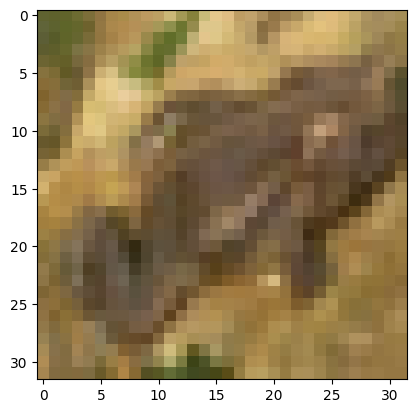

In [5]:
# Function to unnormalize and display an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a random training image
dataiter = iter(torch.utils.data.DataLoader(trainset, batch_size=1, shuffle=True))
image, label = next(dataiter)

# Display the image
imshow(image.squeeze())

# Define CNN Model

In [37]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    # Convolution layer
    self.conv1 = nn.Conv2d(3,16,3,padding=1)
    self.conv2 = nn.Conv2d(16,32,3,padding=1)

    # Pooling layer
    self.pool = nn.MaxPool2d(2,2)

    # Fully Connected layer
    self.fc1 = nn.Linear(32*8*8, 128) # Corrected from 32*7*7
    self.fc2 = nn.Linear(128,10)

    # Activation Function
    self.relu = nn.ReLU()

  def forward(self,x):
    #Conv + Activation + Pool
    x = self.pool(self.relu(self.conv1(x)))
    x = self.pool(self.relu(self.conv2(x)))

    # Flatten
    x = x.view(x.size(0),-1)

    # Fully Connected
    x = self.relu(self.fc1(x))
    x = self.fc2(x)

    return x

# Model Train

In [38]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 64
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

epochs = 10

for epoch in range(epochs):
  running_loss = 0

  for images, labels in train_loader:
    optimizer.zero_grad()

    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print(f'Epoch {epoch+1}, Loss: {running_loss:.3f}')

Epoch 1, Loss: 1137.662
Epoch 2, Loss: 882.007
Epoch 3, Loss: 767.842
Epoch 4, Loss: 692.834
Epoch 5, Loss: 627.982
Epoch 6, Loss: 576.356
Epoch 7, Loss: 528.270
Epoch 8, Loss: 483.907
Epoch 9, Loss: 444.075
Epoch 10, Loss: 401.047


# Normalization

In [39]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Evaluate Model

In [40]:
correct = 0
total = 0
y_true = []
y_pred = []

with torch.no_grad():
  for images, labels in test_loader:
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted.numpy())

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 69.77%


# Precision, Recall, F1

In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.76      0.76      1000
           1       0.83      0.79      0.81      1000
           2       0.66      0.53      0.59      1000
           3       0.53      0.50      0.52      1000
           4       0.52      0.79      0.63      1000
           5       0.64      0.57      0.60      1000
           6       0.85      0.67      0.75      1000
           7       0.73      0.78      0.75      1000
           8       0.78      0.82      0.80      1000
           9       0.80      0.75      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



# Confusion Matrix

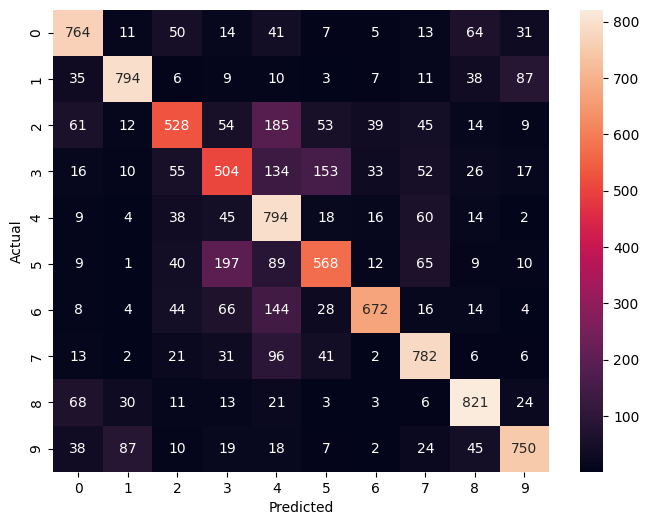

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Visualize Convolution Output

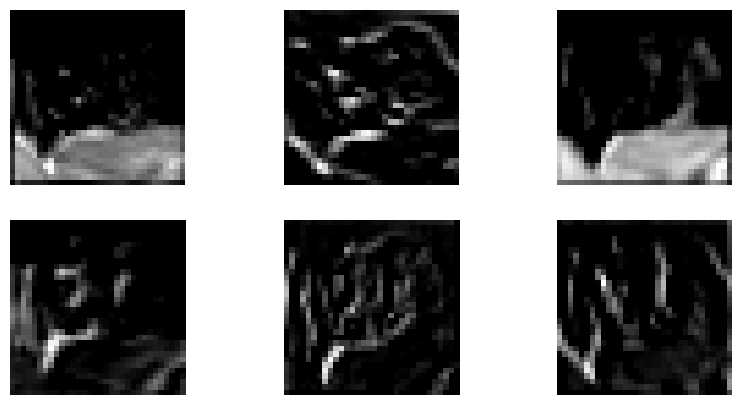

In [43]:
def visualize_feature_maps(model, image):
    model.eval()

    x = image.unsqueeze(0)  # add batch dimension

    # First conv layer output
    x = model.conv1(x)
    x = model.relu(x)

    feature_maps = x.detach().numpy()[0]

    # Plot few feature maps
    plt.figure(figsize=(10,5))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(feature_maps[i], cmap='gray')
        plt.axis('off')
    plt.show()

# Test with one image
img, _ = testset[0]
visualize_feature_maps(model, img)